In [2]:
import os
import numpy as np
import polars as pl
import pandas as pd
from sklearn import metrics
import matplotlib.pyplot as plt

In [3]:
start_year = 2004
end_year = 2009
pred_file = f'../data/offsides_ebgm.csv'
preds = pd.read_csv(pred_file)
preds.head()

,stitch_id,drug,umls_id,event,rr,log2rr,t_statistic,pvalue,observed,expected,bg_correction,sider,future_aers,medeffect,ebgm
0,CID000000076,dehydroepiandrosterone,C0000737,abdominal pain,2.250000,1.169925,6.537095,6.156712e-07,9,4.000000,0.002849,0,0,0,0.995123
1,CID000000076,dehydroepiandrosterone,C0001622,hyperadrenalism,11.000000,3.459432,4.782699,1.644408e-03,2,0.181818,0.000041,0,0,0,25.345244
2,CID000000076,dehydroepiandrosterone,C0001623,adrenal insufficiency,2.200000,1.137504,4.315199,9.884952e-03,2,0.909091,0.002491,0,0,0,1.737803
3,CID000000076,dehydroepiandrosterone,C0002792,anaphylactic reaction,2.588235,1.371969,4.590918,3.355380e-03,4,1.545455,0.000503,0,0,0,1.342789
4,CID000000076,dehydroepiandrosterone,C0002940,aneurysm,7.333333,2.874469,4.598374,3.399457e-03,2,0.272727,0.000135,0,0,0,2.106464


In [4]:
preds = pd.read_csv(pred_file)
preds['reaction'] = preds['event'].str.lower()
preds['drug'] = preds['drug'].str.lower()
preds = preds.dropna()

In [7]:
# negative controls
negative_files = [f for f in os.listdir(f'../results/{start_year}-{end_year}') if f.endswith(f"confounded_examples.csv")]
negative_df = None
for fn in negative_files:
    df = pd.read_csv(os.path.join('../', 'results', f'{start_year}-{end_year}', fn))
    if negative_df is None:
        negative_df = df
    else:
        negative_df = pd.concat([negative_df, df])

negative_df['reaction'] = negative_df['reaction'].str.lower()
negative_df['label'] = 0
negative_df.head()

,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea,conf_drug,sex,age,label
0,Respiratory syncytial virus infection,respiratory syncytial virus infection,acyclovir,0.002712,7.533353,NaN,NaN,NaN,0
1,Respiratory syncytial virus infection,respiratory syncytial virus infection,budesonide,0.003810,10.647726,NaN,NaN,NaN,0
2,Respiratory syncytial virus infection,bronchiolitis,palivizumab,0.412044,1650.161718,NaN,NaN,NaN,0
3,Respiratory syncytial virus infection,cyanosis,palivizumab,0.412044,15.059840,NaN,NaN,NaN,0
4,Respiratory syncytial virus infection,respiratory syncytial virus infection,palivizumab,0.412044,1397.315362,NaN,NaN,NaN,0


In [11]:
# positive controls
fn = '../data/onsides_public_warnings_and_precautions.csv'
positive_df = pd.read_csv(fn)
positive_df['pt_meddra_term'] = positive_df['pt_meddra_term'].str.lower()
positive_df.rename(columns={'pt_meddra_term': 'reaction', 'ingredients_names': 'drug'}, inplace=True)
positive_df['label'] = 1
positive_df.head()
# fn = '../data/onsides_v3_0_0_high_confidence_mapped.csv'
# positive_df = pd.read_csv(fn)
# positive_df['meddra_name'] = positive_df['meddra_name'].str.lower()
# positive_df.rename(columns={'meddra_name': 'reaction', 'rxnorm_name': 'drug'}, inplace=True)
# positive_df['label'] = 1
# positive_df.head()

,ingredients_rxcuis,drug,pt_meddra_id,reaction,label
0,321988,escitalopram,10012218,delirium,1
1,1364347,ponatinib,10003668,atrial tachycardia,1
2,4493,fluoxetine,10025197,lymphadenopathy,1
3,4099,"estrogens, conjugated (USP)",10016807,fluid retention,1
4,753340,sapropterin,10037211,psychomotor hyperactivity,1


In [12]:
reference = pd.concat([positive_df[['drug', 'reaction', 'label']], negative_df[['drug', 'reaction', 'label']]])
reference.tail()

,drug,reaction,label
578,zidovudine,ophthalmoplegia,0
579,zidovudine,retroviral infection,0
580,zidovudine,schistosomiasis,0
581,zidovudine,stillbirth,0
582,zidovudine,tuberculoid leprosy,0


In [13]:
pred_drugs = set(preds.drug.unique())
ref_drugs = set(reference.drug.unique())
len(pred_drugs), len(ref_drugs), len(pred_drugs&ref_drugs)

(1332, 1476, 634)

In [14]:
pred_reactions = set(preds.reaction.unique())
ref_reactions = set(reference.reaction.unique())
len(pred_reactions), len(ref_reactions), len(pred_reactions&ref_reactions)

(10097, 5726, 4232)

In [15]:
merged = pd.merge(preds, reference, on=['drug', 'reaction'], how='inner')
merged.label.sum(), len(merged.label)

(1884, 790986)

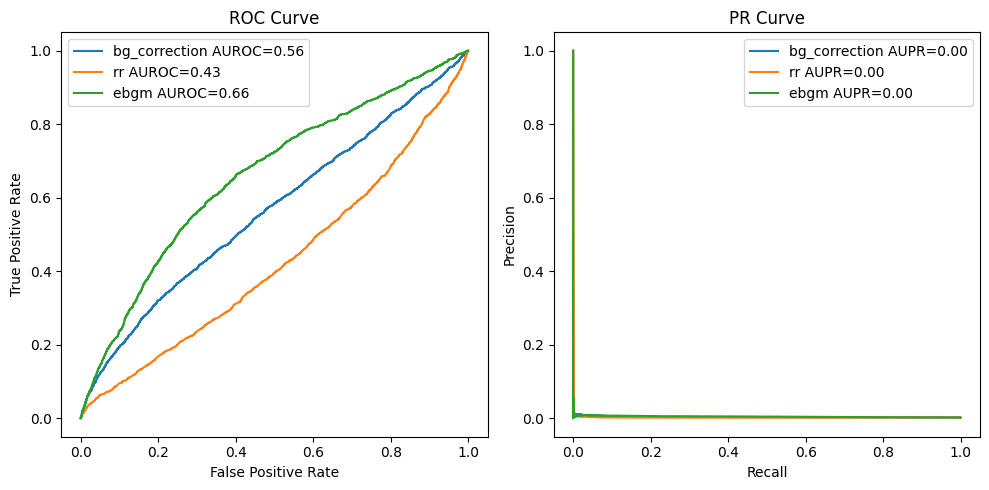

In [16]:
plt.figure(figsize=(10,5))

for col in ('bg_correction', 'rr', 'ebgm'):
    auroc = metrics.roc_auc_score(merged['label'], merged[col])
    aupr = metrics.average_precision_score(merged['label'], merged[col])
    fpr, tpr, thresholds = metrics.roc_curve(merged['label'], merged[col], pos_label=1)

    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f"{col} AUROC={auroc:.2f}")
    
    pr, re, th = metrics.precision_recall_curve(merged['label'], merged[col])
    plt.subplot(1,2,2)
    plt.plot(re, pr, label=f"{col} AUPR={aupr:.2f}")

plt.subplot(1,2,1)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1,2,2)
plt.title('PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()

plt.tight_layout()
plt.savefig(f'../results/{start_year}-{end_year}/offsides_v1_confounding_performance_roc_pr_curves.pdf')

In [17]:
neg = merged[col][merged['label']==0]
pos = merged[col][merged['label']==1]
neg.mean(), pos.mean()

(3.6868875459755257, 8.724649682180713)